In [1]:
from datasets import load_dataset

/Users/viktorzozula/MemoriesTesting/PersonaMem0/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("bowen-upenn/PersonaMem-v2")

In [3]:
ds.data.keys()

dict_keys(['benchmark_multimodal', 'train_multimodal', 'val_multimodal', 'benchmark_text', 'train_text', 'val_text'])

## Quick inspection helpers

The cells below help you understand what was downloaded:
- what splits exist and how many rows each has
- what columns/features each split contains
- what a few raw examples look like (and how to view images if present)


In [4]:
from pprint import pprint

# ds is a DatasetDict
print(ds)
print("\nSplits:", list(ds.keys()))
print("Row counts:")
for k in ds.keys():
    print(f"- {k:>20}: {ds[k].num_rows}")


DatasetDict({
    benchmark_multimodal: Dataset({
        features: ['persona_id', 'chat_history_32k_link', 'chat_history_128k_link', 'raw_persona_file', 'short_persona', 'expanded_persona', 'user_query', 'correct_answer', 'incorrect_answers', 'topic_query', 'preference', 'topic_preference', 'conversation_scenario', 'pref_type', 'related_conversation_snippet', 'who', 'updated', 'prev_pref', 'sensitive_info', 'total_tokens_in_chat_history_32k', 'total_tokens_in_chat_history_128k', 'distance_from_related_snippet_to_query_32k', 'distance_from_related_snippet_to_query_128k', 'num_persona_relevant_tokens_32k', 'num_persona_irrelevant_tokens_32k', 'num_persona_relevant_tokens_128k', 'num_persona_irrelevant_tokens_128k'],
        num_rows: 5000
    })
    train_multimodal: Dataset({
        features: ['persona_id', 'chat_history_32k_link', 'chat_history_128k_link', 'raw_persona_file', 'short_persona', 'expanded_persona', 'user_query', 'correct_answer', 'incorrect_answers', 'topic_query', 'pre

In [5]:
def describe_split(name: str, n_examples: int = 2):
    d = ds[name]
    print("=" * 80)
    print(name)
    print("rows:", d.num_rows)
    print("columns:", d.column_names)
    print("\nfeatures:")
    pprint(d.features)

    print("\nexample(s):")
    for i in range(min(n_examples, d.num_rows)):
        ex = d[i]
        print(f"\n[{name}][{i}]")
        # Keep this as raw dict so you can see nested structure.
        pprint(ex)


describe_split("benchmark_text", n_examples=1)


benchmark_text
rows: 5000
columns: ['persona_id', 'chat_history_32k_link', 'chat_history_128k_link', 'raw_persona_file', 'short_persona', 'expanded_persona', 'user_query', 'correct_answer', 'incorrect_answers', 'topic_query', 'preference', 'topic_preference', 'conversation_scenario', 'pref_type', 'related_conversation_snippet', 'who', 'updated', 'prev_pref', 'sensitive_info', 'total_tokens_in_chat_history_32k', 'total_tokens_in_chat_history_128k', 'distance_from_related_snippet_to_query_32k', 'distance_from_related_snippet_to_query_128k', 'num_persona_relevant_tokens_32k', 'num_persona_irrelevant_tokens_32k', 'num_persona_relevant_tokens_128k', 'num_persona_irrelevant_tokens_128k']

features:
{'chat_history_128k_link': Value('string'),
 'chat_history_32k_link': Value('string'),
 'conversation_scenario': Value('string'),
 'correct_answer': Value('string'),
 'distance_from_related_snippet_to_query_128k': Value('int64'),
 'distance_from_related_snippet_to_query_32k': Value('int64'),
 'exp

In [6]:
# If the multimodal split contains images (datasets.Image), this helper will display one.
# (Safe to run even if there are no images.)

def try_show_first_image(split_name: str = "train_multimodal"):
    d = ds[split_name]

    image_cols = []
    for col, feat in d.features.items():
        if feat.__class__.__name__ == "Image":
            image_cols.append(col)

    if not image_cols:
        print(f"No Image columns found in {split_name}.")
        return

    col = image_cols[0]
    ex0 = d[0]
    img = ex0[col]
    print(f"Showing {split_name}[0][{col}] ->", type(img))

    # datasets.Image returns a dict-like object or PIL image depending on decode.
    try:
        pil = img["image"] if isinstance(img, dict) and "image" in img else img
        display(pil)
    except Exception as e:
        print("Could not display image:", e)
        print("Raw value:")
        pprint(img)


try_show_first_image("train_multimodal")


No Image columns found in train_multimodal.


In [7]:
# Where is it cached locally?
# This is useful to confirm what was downloaded and where.

for k in ds.keys():
    d = ds[k]
    print("=" * 80)
    print(k)
    try:
        pprint(d.cache_files)
    except Exception as e:
        print("No cache_files info:", e)


benchmark_multimodal
[{'filename': '/Users/viktorzozula/.cache/huggingface/datasets/bowen-upenn___persona_mem-v2/benchmark/0.0.0/87abb2e774588a8bc97d939640ac2843c84aa1f1/persona_mem-v2-benchmark_multimodal.arrow'}]
train_multimodal
[{'filename': '/Users/viktorzozula/.cache/huggingface/datasets/bowen-upenn___persona_mem-v2/benchmark/0.0.0/87abb2e774588a8bc97d939640ac2843c84aa1f1/persona_mem-v2-train_multimodal.arrow'}]
val_multimodal
[{'filename': '/Users/viktorzozula/.cache/huggingface/datasets/bowen-upenn___persona_mem-v2/benchmark/0.0.0/87abb2e774588a8bc97d939640ac2843c84aa1f1/persona_mem-v2-val_multimodal.arrow'}]
benchmark_text
[{'filename': '/Users/viktorzozula/.cache/huggingface/datasets/bowen-upenn___persona_mem-v2/benchmark/0.0.0/87abb2e774588a8bc97d939640ac2843c84aa1f1/persona_mem-v2-benchmark_text.arrow'}]
train_text
[{'filename': '/Users/viktorzozula/.cache/huggingface/datasets/bowen-upenn___persona_mem-v2/benchmark/0.0.0/87abb2e774588a8bc97d939640ac2843c84aa1f1/persona_mem-

In [8]:
# Robust way to open `chat_history_32k_link` / `raw_persona_file` etc.
# These files live in the HF *dataset repo* and are best fetched via the Hub helpers.

import json
from huggingface_hub import hf_hub_download

DATASET_REPO = "bowen-upenn/PersonaMem-v2"


def open_repo_json(filename: str) -> tuple[str, dict]:
    """Download (if needed) and open a JSON file from the dataset repo."""
    local_path = hf_hub_download(
        repo_id=DATASET_REPO,
        repo_type="dataset",
        filename=filename,
    )
    with open(local_path, "r") as f:
        return local_path, json.load(f)


row = ds["benchmark_text"][0]
local_path, history = open_repo_json(row["chat_history_32k_link"])
print("persona_id:", row["persona_id"])
print("chat_history_32k_link:", row["chat_history_32k_link"])
print("local_path:", local_path)

# Quick peek at structure
if isinstance(history, dict):
    print("top-level keys:", list(history.keys())[:25])
else:
    print("history type:", type(history))

# Raw preview (first ~40 lines)
print("\n--- raw preview ---")
with open(local_path, "r") as f:
    for i in range(40):
        line = f.readline()
        if not line:
            break
        print(line.rstrip("\n"))


persona_id: 521
chat_history_32k_link: data/chat_history_32k/chat_history_250913_163134_persona521.json
local_path: /Users/viktorzozula/.cache/huggingface/hub/datasets--bowen-upenn--PersonaMem-v2/snapshots/87abb2e774588a8bc97d939640ac2843c84aa1f1/data/chat_history_32k/chat_history_250913_163134_persona521.json
top-level keys: ['metadata', 'chat_history']

--- raw preview ---
{
  "metadata": {
    "total_messages": 189,
    "final_token_count": 31842,
    "persona_id": 521,
    "input_filename": "data/raw_data/raw_data_250819_225921_persona521.json"
  },
  "chat_history": [
    {
      "role": "system",
      "content": "You are an AI assistant helping a user with the following persona:\n\n{\n  \"short_persona\": {\n    \"persona\": \"A liberal Democrat from Kansas, slightly skeptical about Republican candidates, but also respects politicians' personal lives.\"\n  },\n  \"name\": \"Daniel Robert Whitaker\",\n  \"age\": 38,\n  \"gender\": \"Male\",\n  \"sexual_orientation\": \"Heterosexu

In [9]:
# Are rows already grouped by user? Not physically.
# But you can confirm each persona_id maps to (usually) one history file.

import pandas as pd

split = "benchmark_text"
df = ds[split].to_pandas()

print("rows:", len(df))
print("unique persona_id:", df["persona_id"].nunique())

n_unique_histories = (
    df.groupby("persona_id")["chat_history_32k_link"].nunique().describe()
)
print("\n#unique chat_history_32k_link per persona_id (describe):")
print(n_unique_histories)

# If you want per-user evaluation batches:
# each group = one persona_id, with many query rows
example_pid = int(df["persona_id"].iloc[0])
user_rows = df[df["persona_id"] == example_pid]
print(f"\nExample persona_id={example_pid} has {len(user_rows)} rows")
print("history file:", user_rows["chat_history_32k_link"].iloc[0])


rows: 5000
unique persona_id: 200

#unique chat_history_32k_link per persona_id (describe):
count    200.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: chat_history_32k_link, dtype: float64

Example persona_id=521 has 26 rows
history file: data/chat_history_32k/chat_history_250913_163134_persona521.json


100%|██████████| 200/200 [00:37<00:00,  5.26it/s]


Users: 200

Messages per user (summary):
count    200.000000
mean     233.165000
std       23.816463
min      162.000000
25%      220.000000
50%      234.000000
75%      249.000000
max      293.000000
Name: n_messages, dtype: float64

TOTAL messages across all users: 46633


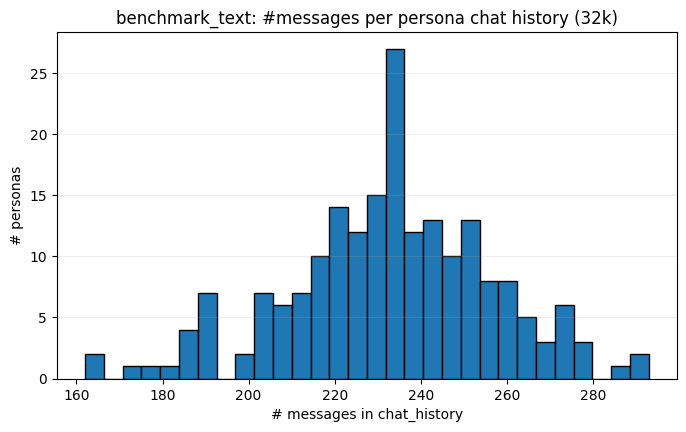


Smallest 5:


,persona_id,chat_history_32k_link,n_messages,n_messages_from_meta,n_messages_from_list
0,10,data/chat_history_32k/chat_history_250913_1631...,162,162,162
81,408,data/chat_history_32k/chat_history_250913_1631...,166,166,166
162,822,data/chat_history_32k/chat_history_250913_1631...,175,175,175
65,318,data/chat_history_32k/chat_history_250913_1631...,179,179,179
178,899,data/chat_history_32k/chat_history_250913_1631...,182,182,182



Largest 5:


,persona_id,chat_history_32k_link,n_messages,n_messages_from_meta,n_messages_from_list
180,902,data/chat_history_32k/chat_history_250913_1631...,293,293,293
171,866,data/chat_history_32k/chat_history_250913_1631...,290,290,290
11,66,data/chat_history_32k/chat_history_250913_1631...,285,285,285
111,578,data/chat_history_32k/chat_history_250913_1631...,278,278,278
140,689,data/chat_history_32k/chat_history_250913_1631...,278,278,278


In [10]:
# Count + plot number of messages per user's chat history (for one split)

import numpy as np
from tqdm.auto import tqdm

split = "benchmark_text"  # change to train_text / val_text / multimodal splits if desired

df = ds[split].to_pandas()
user_hist = (
    df.groupby("persona_id", as_index=False)["chat_history_32k_link"].first()
    .sort_values("persona_id")
)

rows = []
for pid, link in tqdm(user_hist[["persona_id", "chat_history_32k_link"]].itertuples(index=False), total=len(user_hist)):
    _, obj = open_repo_json(link)

    n_from_meta = None
    if isinstance(obj, dict):
        n_from_meta = obj.get("metadata", {}).get("total_messages")

    chat = obj.get("chat_history") if isinstance(obj, dict) else None
    n_from_list = len(chat) if isinstance(chat, list) else None

    n = n_from_meta if n_from_meta is not None else n_from_list
    rows.append(
        {
            "persona_id": int(pid),
            "chat_history_32k_link": link,
            "n_messages": int(n) if n is not None else np.nan,
            "n_messages_from_meta": n_from_meta,
            "n_messages_from_list": n_from_list,
        }
    )

msg_counts = pd.DataFrame(rows)

print("Users:", len(msg_counts))
print("\nMessages per user (summary):")
print(msg_counts["n_messages"].describe())

total_messages = int(msg_counts["n_messages"].sum())
print("\nTOTAL messages across all users:", total_messages)

# Plot
try:
    import matplotlib.pyplot as plt
except ImportError:
    import sys

    # Install matplotlib into the current kernel env, then import
    !"{sys.executable}" -m pip install -q matplotlib
    import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.5))
plt.hist(msg_counts["n_messages"].dropna(), bins=30, edgecolor="black")
plt.title(f"{split}: #messages per persona chat history (32k)")
plt.xlabel("# messages in chat_history")
plt.ylabel("# personas")
plt.grid(axis="y", alpha=0.2)
plt.show()

# Optional: look at extremes
print("\nSmallest 5:")
display(msg_counts.sort_values("n_messages").head(5))
print("\nLargest 5:")
display(msg_counts.sort_values("n_messages", ascending=False).head(5))


In [11]:
# Estimate how many *tokens* all chat histories would cost to ingest into mem0.
# We use the dataset-provided `metadata.final_token_count` per history as a proxy.

from huggingface_hub import list_repo_files
from tqdm.auto import tqdm

# 1) List all 32k chat history JSONs in the dataset repo
all_files = list_repo_files(repo_id=DATASET_REPO, repo_type="dataset")
chat32_files = [f for f in all_files if f.startswith("data/chat_history_32k/") and f.endswith(".json")]
print(f"Found {len(chat32_files)} 32k chat history files.")

# 2) Sum up their `metadata.final_token_count`

total_final_tokens = 0
missing_meta = 0
per_file_tokens = []

for fpath in tqdm(chat32_files):
    _, obj = open_repo_json(fpath)
    meta = obj.get("metadata", {}) if isinstance(obj, dict) else {}
    n = meta.get("final_token_count")
    if isinstance(n, int):
        total_final_tokens += n
        per_file_tokens.append(n)
    else:
        missing_meta += 1

print("\nChat histories with missing final_token_count in metadata:", missing_meta)
print("Total tokens across all 32k histories (metadata.final_token_count):", total_final_tokens)

# 3) Optional sanity check with a real tokenizer (e.g., tiktoken for OpenAI models)

try:
    import tiktoken

    enc = tiktoken.encoding_for_model("gpt-4.1-mini")  # adjust to your mem0 model

    def count_tokens_messages(chat_history):
        # Very simple: join role + content; you can make this closer
        # to your actual chat format if needed.
        texts = []
        for msg in chat_history:
            role = msg.get("role", "")
            content = msg.get("content", "")
            texts.append(f"{role}: {content}")
        return len(enc.encode("\n".join(texts)))

    # Sample a few histories and compare metadata vs tokenizer count
    import random

    sample_files = random.sample(chat32_files, min(5, len(chat32_files)))
    print("\nSanity check on a few files (metadata vs tokenizer):")
    for fpath in sample_files:
        _, obj = open_repo_json(fpath)
        chat = obj.get("chat_history", []) if isinstance(obj, dict) else []
        meta_n = obj.get("metadata", {}).get("final_token_count")
        tok_n = count_tokens_messages(chat)
        print(f"{fpath} -> meta={meta_n}, tokenizer={tok_n}")

except ImportError:
    print("tiktoken not installed; install it if you want tokenizer-based estimates:")
    print("  pip install tiktoken")


Found 1998 32k chat history files.


100%|██████████| 1998/1998 [06:32<00:00,  5.09it/s]



Chat histories with missing final_token_count in metadata: 0
Total tokens across all 32k histories (metadata.final_token_count): 62414331

Sanity check on a few files (metadata vs tokenizer):
data/chat_history_32k/chat_history_250913_163134_persona811.json -> meta=31620, tokenizer=32160
data/chat_history_32k/chat_history_250913_163134_persona739.json -> meta=31632, tokenizer=32054
data/chat_history_32k/chat_history_250913_163134_persona121.json -> meta=31995, tokenizer=32565
data/chat_history_32k/chat_history_250913_163134_persona205.json -> meta=31824, tokenizer=32375
data/chat_history_32k/chat_history_250913_163134_persona743.json -> meta=31997, tokenizer=32533


In [12]:
import pandas as pd

In [13]:
# Get per-user bundle: chat_history JSON + all benchmark rows for that persona_id

from typing import Any, Optional

_split_df_cache: dict[str, pd.DataFrame] = {}


def get_user_bundle(
    user_id: int,
    split: str = "benchmark_text",
    history_col: str = "chat_history_32k_link",
    include_persona_file: bool = False,
) -> dict[str, Any]:
    """Return chat history + all rows for one user (persona).

    Parameters
    ----------
    user_id:
        The dataset's persona identifier (same as `persona_id`).
    split:
        Which split to pull the benchmark rows from (e.g. 'benchmark_text').
    history_col:
        Which history link column to use: 'chat_history_32k_link' or 'chat_history_128k_link'.
        (In multimodal splits this still works; the link points to multimodal history files.)
    include_persona_file:
        If True, also downloads and returns the raw persona JSON referenced by `raw_persona_file`.

    Returns
    -------
    dict with keys:
      - persona_id
      - split
      - chat_history_path (repo path)
      - chat_history_local_path
      - chat_history_json
      - benchmark_rows_df (all rows for that persona_id in the split)
      - raw_persona_file_* (optional)
    """

    if split not in ds:
        raise ValueError(f"Unknown split: {split}. Available: {list(ds.keys())}")

    if split not in _split_df_cache:
        _split_df_cache[split] = ds[split].to_pandas()

    df = _split_df_cache[split]
    user_rows = df[df["persona_id"] == int(user_id)].copy()

    if user_rows.empty:
        raise ValueError(
            f"No rows for persona_id={user_id} in split='{split}'. "
            f"(Try a different split.)"
        )

    if history_col not in user_rows.columns:
        raise ValueError(
            f"Column '{history_col}' not found in split='{split}'. "
            f"Available columns: {list(user_rows.columns)}"
        )

    chat_repo_path = str(user_rows[history_col].iloc[0])
    chat_local_path, chat_json = open_repo_json(chat_repo_path)

    out: dict[str, Any] = {
        "persona_id": int(user_id),
        "split": split,
        "chat_history_path": chat_repo_path,
        "chat_history_local_path": chat_local_path,
        "chat_history_json": chat_json,
        "benchmark_rows_df": user_rows.reset_index(drop=True),
    }

    if include_persona_file:
        raw_persona_repo_path = str(user_rows["raw_persona_file"].iloc[0])
        raw_persona_local_path, raw_persona_json = open_repo_json(raw_persona_repo_path)
        out.update(
            {
                "raw_persona_file_path": raw_persona_repo_path,
                "raw_persona_file_local_path": raw_persona_local_path,
                "raw_persona_file_json": raw_persona_json,
            }
        )

    return out

In [21]:
# Example usage:
bundle = get_user_bundle(
    521, 
    split="benchmark_multimodal", 
    history_col="chat_history_32k_link", 
    include_persona_file=True
)
bundle["chat_history_json"].keys(), bundle["benchmark_rows_df"].shape


(dict_keys(['metadata', 'chat_history']), (27, 27))

In [22]:
# Export per-user bundles to JSONL (chat_history + benchmark rows)

from __future__ import annotations

import json
from pathlib import Path
from typing import Iterable


def get_user_bundle_multi(
    user_id: int,
    splits: Iterable[str] = ("benchmark_multimodal",),
    history_col: str = "chat_history_32k_link",
    include_persona_file: bool = False,
) -> dict[str, Any]:
    """Like get_user_bundle, but supports multiple splits and returns rows per split."""

    splits = tuple(splits)
    if not splits:
        raise ValueError("splits must be non-empty")

    # Collect rows for this user across requested splits
    rows_by_split: dict[str, pd.DataFrame] = {}
    history_repo_path: Optional[str] = None
    raw_persona_repo_path: Optional[str] = None

    for split in splits:
        if split not in ds:
            raise ValueError(f"Unknown split: {split}. Available: {list(ds.keys())}")

        if split not in _split_df_cache:
            _split_df_cache[split] = ds[split].to_pandas()

        df = _split_df_cache[split]
        user_rows = df[df["persona_id"] == int(user_id)].copy()
        rows_by_split[split] = user_rows

        if history_repo_path is None and not user_rows.empty:
            if history_col not in user_rows.columns:
                raise ValueError(
                    f"Column '{history_col}' not found in split='{split}'. "
                    f"Available columns: {list(user_rows.columns)}"
                )
            history_repo_path = str(user_rows[history_col].iloc[0])

        if raw_persona_repo_path is None and not user_rows.empty and "raw_persona_file" in user_rows.columns:
            raw_persona_repo_path = str(user_rows["raw_persona_file"].iloc[0])

    if history_repo_path is None:
        raise ValueError(f"persona_id={user_id} not found in any of splits={splits}")

    chat_local_path, chat_json = open_repo_json(history_repo_path)

    out: dict[str, Any] = {
        "persona_id": int(user_id),
        "splits": list(splits),
        "chat_history_path": history_repo_path,
        "chat_history_local_path": chat_local_path,
        "chat_history_json": chat_json,
        "rows_by_split": {
            split: df.reset_index(drop=True).to_dict(orient="records")
            for split, df in rows_by_split.items()
        },
    }

    if include_persona_file and raw_persona_repo_path is not None:
        raw_local_path, raw_json = open_repo_json(raw_persona_repo_path)
        out.update(
            {
                "raw_persona_file_path": raw_persona_repo_path,
                "raw_persona_file_local_path": raw_local_path,
                "raw_persona_file_json": raw_json,
            }
        )

    return out


def export_user_bundles_jsonl(
    out_path: str | Path,
    splits: Iterable[str] = ("benchmark_text",),
    history_col: str = "chat_history_32k_link",
    include_persona_file: bool = False,
) -> Path:
    """Write one JSON object per user (persona_id) into a JSONL file."""

    out_path = Path(out_path)

    # Union persona_ids across splits
    persona_ids: set[int] = set()
    for split in splits:
        if split not in _split_df_cache:
            _split_df_cache[split] = ds[split].to_pandas()
        persona_ids |= set(_split_df_cache[split]["persona_id"].astype(int).unique().tolist())

    persona_ids_sorted = sorted(persona_ids)
    print(f"Exporting {len(persona_ids_sorted)} users to {out_path}...")

    out_path.parent.mkdir(parents=True, exist_ok=True)

    with out_path.open("w", encoding="utf-8") as f:
        for pid in tqdm(persona_ids_sorted):
            bundle = get_user_bundle_multi(
                pid,
                splits=splits,
                history_col=history_col,
                include_persona_file=include_persona_file,
            )
            f.write(json.dumps(bundle, ensure_ascii=False))
            f.write("\n")

    print("Done.")
    return out_path


In [23]:
# Example run (benchmark users only):
out = export_user_bundles_jsonl(
    "exports/personamem_benchmark_multimodal_32k_user_bundles.jsonl",
    splits=("benchmark_multimodal",),
    history_col="chat_history_32k_link",
    include_persona_file=False,
)
out

Exporting 195 users to exports/personamem_benchmark_multimodal_32k_user_bundles.jsonl...


100%|██████████| 195/195 [01:11<00:00,  2.74it/s]

Done.


PosixPath('exports/personamem_benchmark_multimodal_32k_user_bundles.jsonl')